### Graficas o insights para Financiación ICETEX (créditos académicos, financieros y de continuidad)

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sbn
import numpy as np

In [2]:
# cargamos el dataset
ROOT = Path('..').resolve()
icetex = pd.read_csv(ROOT/'icetex.csv', sep=';')
display(icetex.head())

,ACADE,FINAN,CI_RECI,TIPO,1998-1,1998-2,1999-1,1999-2,2000-1,2000-2,...,2020-1,2020-2,2021-1,2021-2,2022-1,2022-2,2023-1,2023-2,2024-1,2024-2
0,Sin Informaci¿n,Sin Informaci¿n,Sin Informaci¿n,DESERTORES,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Sin Informaci¿n,Sin Informaci¿n,Ninguno,DESERTORES,0.0,0.0,0.0,0.0,0.0,0.0,...,20,30.0,21,37.0,39.0,29.0,22.0,20.0,22.0,46.0
2,Sin Informaci¿n,Sin Informaci¿n,1 a 3,DESERTORES,NaN,NaN,NaN,NaN,NaN,NaN,...,2,3.0,2,2.0,3.0,2.0,1.0,2.0,3.0,1.0
3,Sin Informaci¿n,Sin Informaci¿n,4 a 6,DESERTORES,NaN,NaN,NaN,NaN,NaN,NaN,...,2,2.0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,Sin Informaci¿n,Sin Informaci¿n,M¿s de 7,DESERTORES,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Exploramos las columnas y datos que tenemos así como su tipo
display(icetex.info())
display(icetex['ACADE'].value_counts())
display(icetex['FINAN'].value_counts())
display(icetex['CI_RECI'].value_counts())
display(icetex['TIPO'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 58 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ACADE    250 non-null    object 
 1   FINAN    250 non-null    object 
 2   CI_RECI  250 non-null    object 
 3   TIPO     250 non-null    object 
 4   1998-1   168 non-null    float64
 5   1998-2   174 non-null    float64
 6   1999-1   194 non-null    float64
 7   1999-2   200 non-null    float64
 8   2000-1   204 non-null    float64
 9   2000-2   214 non-null    float64
 10  2001-1   220 non-null    float64
 11  2001-2   218 non-null    float64
 12  2002-1   218 non-null    float64
 13  2002-2   222 non-null    float64
 14  2003-1   232 non-null    float64
 15  2003-2   232 non-null    float64
 16  2004-1   244 non-null    float64
 17  2004-2   246 non-null    float64
 18  2005-1   246 non-null    float64
 19  2005-2   248 non-null    float64
 20  2006-1   250 non-null    int64  
 21  2006-2   250 non

None

ACADE
Sin Informaci¿n    50
Ninguno            50
1 a 3              50
4 a 6              50
M¿s de 7           50
Name: count, dtype: int64

FINAN
Sin Informaci¿n    50
Ninguno            50
1 a 3              50
4 a 6              50
M¿s de 7           50
Name: count, dtype: int64

CI_RECI
Sin Informaci¿n    50
Ninguno            50
1 a 3              50
4 a 6              50
M¿s de 7           50
Name: count, dtype: int64

TIPO
DESERTORES      125
MATRICULADOS    125
Name: count, dtype: int64

A diferencia de los datasets anteriores, aquí no hay una columna identitaria como `SEXO` que filtrar — `ACADE`, `FINAN` y `CI_RECI` son las variables de interés en sí mismas (rangos de créditos ICETEX recibidos: académicos, financieros/subsistencia, y de continuidad). Cada combinación de las 3 está presente (incluyendo "Sin Información"), así que no eliminamos filas, vamos directo al melt.

Hacemos la conversión de formato ancho a formato largo

In [4]:
columnas_stay = ['ACADE','FINAN','CI_RECI','TIPO']
columnas_melt = [col for col in icetex.columns if col not in columnas_stay]
print(columnas_melt)
long_icetex = icetex.melt(
    id_vars=columnas_stay,
    value_vars=columnas_melt,       # lista de '2015-1', '2015-2', ...
    var_name='periodo',
    value_name='valor'
)
display(long_icetex.head())

['1998-1', '1998-2', '1999-1', '1999-2', '2000-1', '2000-2', '2001-1', '2001-2', '2002-1', '2002-2', '2003-1', '2003-2', '2004-1', '2004-2', '2005-1', '2005-2', '2006-1', '2006-2', '2007-1', '2007-2', '2008-1', '2008-2', '2009-1', '2009-2', '2010-1', '2010-2', '2011-1', '2011-2', '2012-1', '2012-2', '2013-1', '2013-2', '2014-1', '2014-2', '2015-1', '2015-2', '2016-1', '2016-2', '2017-1', '2017-2', '2018-1', '2018-2', '2019-1', '2019-2', '2020-1', '2020-2', '2021-1', '2021-2', '2022-1', '2022-2', '2023-1', '2023-2', '2024-1', '2024-2']


,ACADE,FINAN,CI_RECI,TIPO,periodo,valor
0,Sin Informaci¿n,Sin Informaci¿n,Sin Informaci¿n,DESERTORES,1998-1,NaN
1,Sin Informaci¿n,Sin Informaci¿n,Ninguno,DESERTORES,1998-1,0.0
2,Sin Informaci¿n,Sin Informaci¿n,1 a 3,DESERTORES,1998-1,NaN
3,Sin Informaci¿n,Sin Informaci¿n,4 a 6,DESERTORES,1998-1,NaN
4,Sin Informaci¿n,Sin Informaci¿n,M¿s de 7,DESERTORES,1998-1,NaN


Verificamos NaNs o nulls para limpiar

In [5]:
print(long_icetex.isnull().sum())

ACADE        0
FINAN        0
CI_RECI      0
TIPO         0
periodo      0
valor      604
dtype: int64


In [6]:
pivot = long_icetex.pivot_table(
    index=['ACADE','FINAN','CI_RECI','periodo'],
    columns='TIPO',
    values='valor',
    aggfunc=lambda x: x.sum(min_count=1)
).reset_index()
display(pivot.head())

TIPO,ACADE,FINAN,CI_RECI,periodo,DESERTORES,MATRICULADOS
0,1 a 3,1 a 3,1 a 3,1998-1,0.0,48.0
1,1 a 3,1 a 3,1 a 3,1998-2,0.0,68.0
2,1 a 3,1 a 3,1 a 3,1999-1,5.0,81.0
3,1 a 3,1 a 3,1 a 3,1999-2,18.0,102.0
4,1 a 3,1 a 3,1 a 3,2000-1,3.0,159.0


Calculamos la tasa de deserción y corregimos outliers (mismo criterio que en los notebooks anteriores: acotamos a [0, 100])

In [7]:
pivot['tasa'] = round((pivot['DESERTORES'] / pivot['MATRICULADOS']) * 100, 2)
pivot['tasa'] = np.clip(pivot['tasa'], 0, 100)
display(pivot.head())

TIPO,ACADE,FINAN,CI_RECI,periodo,DESERTORES,MATRICULADOS,tasa
0,1 a 3,1 a 3,1 a 3,1998-1,0.0,48.0,0.00
1,1 a 3,1 a 3,1 a 3,1998-2,0.0,68.0,0.00
2,1 a 3,1 a 3,1 a 3,1999-1,5.0,81.0,6.17
3,1 a 3,1 a 3,1 a 3,1999-2,18.0,102.0,17.65
4,1 a 3,1 a 3,1 a 3,2000-1,3.0,159.0,1.89


### Gráficas

Las categorías de `ACADE`, `FINAN` y `CI_RECI` tienen un orden lógico (`Ninguno` < `1 a 3` < `4 a 6` < `Más de 7`), así que las ordenamos explícitamente en el eje X en vez de dejar el orden alfabético por defecto.

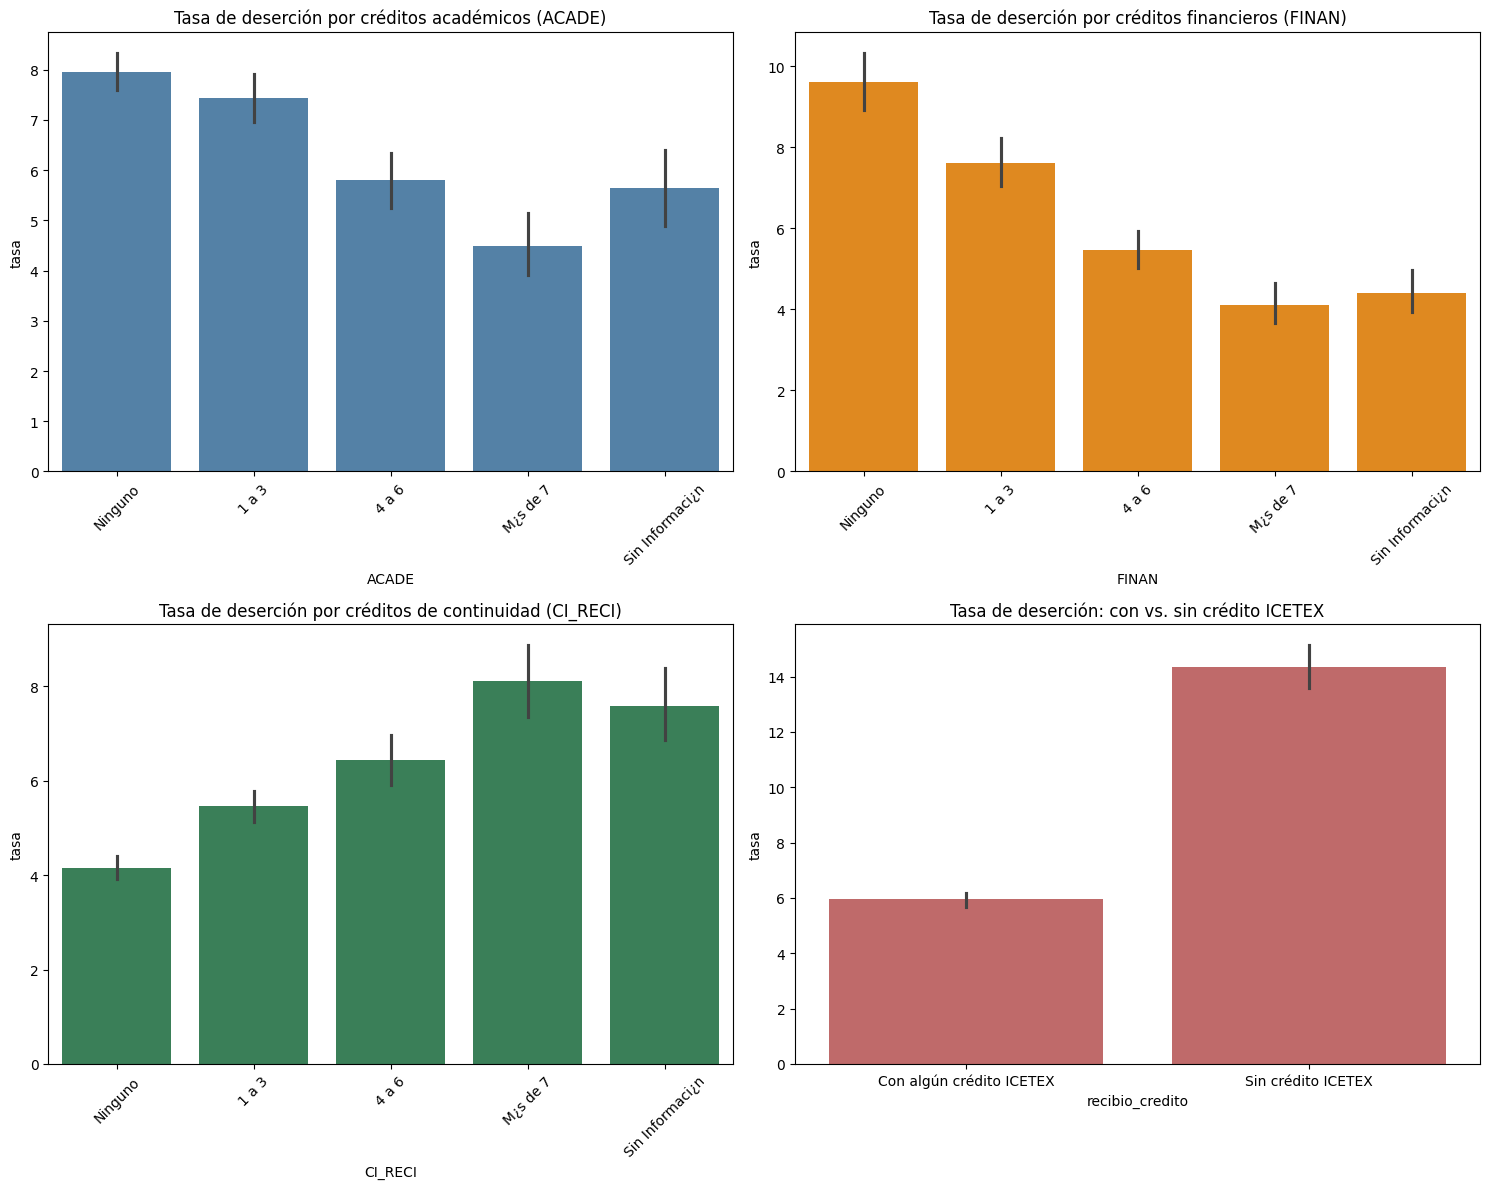

In [8]:
orden_creditos = ['Ninguno', '1 a 3', '4 a 6', 'M¿s de 7', 'Sin Informaci¿n']

fig, axs = plt.subplots(2, 2, figsize=(15, 12))

sbn.barplot(data=pivot, x='ACADE', y='tasa', order=orden_creditos, ax=axs[0,0], color='steelblue')
axs[0,0].tick_params(axis='x', rotation=45)
axs[0,0].set_title('Tasa de deserción por créditos académicos (ACADE)')

sbn.barplot(data=pivot, x='FINAN', y='tasa', order=orden_creditos, ax=axs[0,1], color='darkorange')
axs[0,1].tick_params(axis='x', rotation=45)
axs[0,1].set_title('Tasa de deserción por créditos financieros (FINAN)')

sbn.barplot(data=pivot, x='CI_RECI', y='tasa', order=orden_creditos, ax=axs[1,0], color='seagreen')
axs[1,0].tick_params(axis='x', rotation=45)
axs[1,0].set_title('Tasa de deserción por créditos de continuidad (CI_RECI)')

pivot['recibio_credito'] = np.where(
    (pivot['ACADE'] == 'Ninguno') & (pivot['FINAN'] == 'Ninguno'),
    'Sin crédito ICETEX',
    'Con algún crédito ICETEX'
)
sbn.barplot(data=pivot, x='recibio_credito', y='tasa', ax=axs[1,1], color='indianred')
axs[1,1].set_title('Tasa de deserción: con vs. sin crédito ICETEX')

plt.tight_layout()
plt.show()

Evolución de la tasa de deserción por créditos académicos (ACADE) a través del tiempo

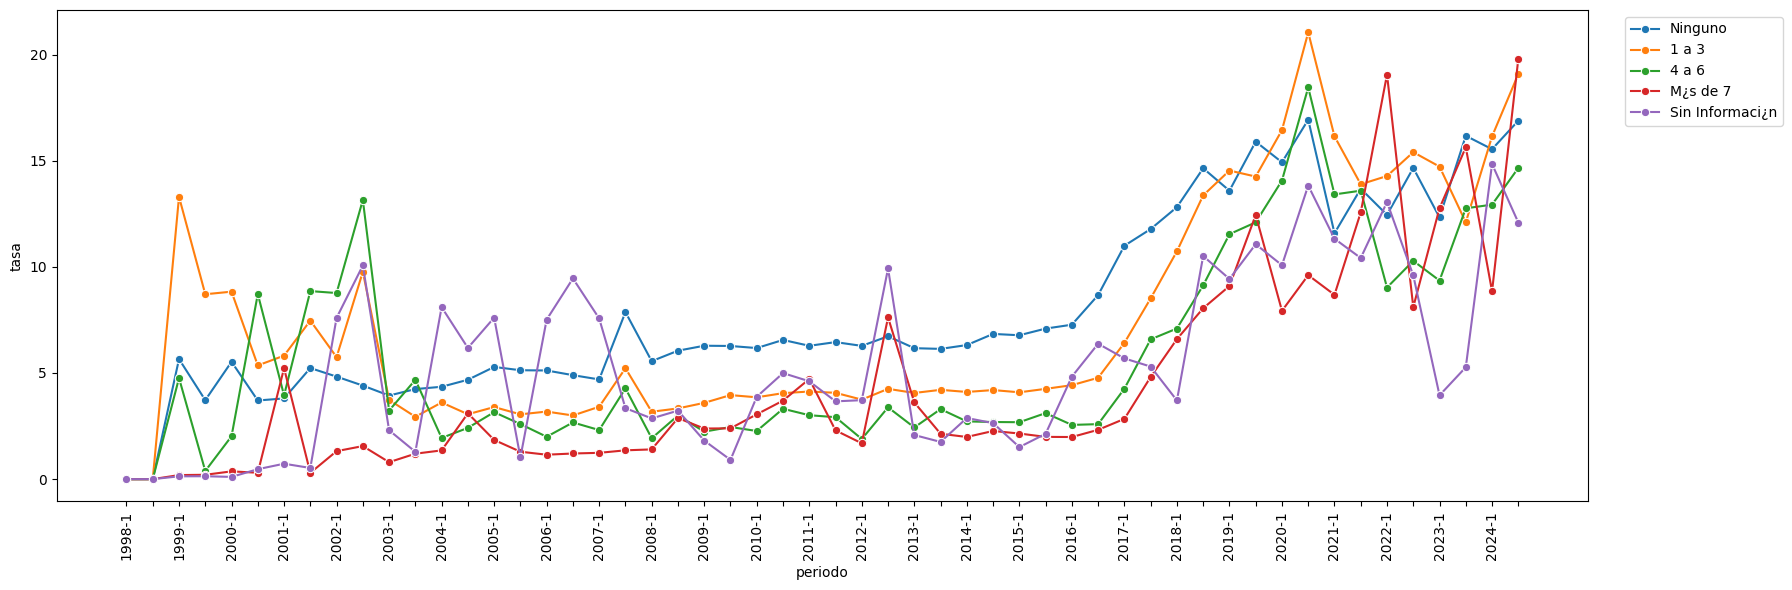

In [9]:
f = pivot.groupby(['ACADE','periodo'])['tasa'].mean().reset_index()

# Forzamos orden cronológico explícito en el eje X (lección aprendida en
# sex_programa.ipynb: lineplot ordena por orden de aparición, no alfabético,
# cuando las categorías no arrancan todas en el mismo período)
orden_periodos = sorted(f['periodo'].unique())
f['periodo'] = pd.Categorical(f['periodo'], categories=orden_periodos, ordered=True)
f = f.sort_values('periodo')

plt.figure(figsize=(18,6))
ax = sbn.lineplot(data=f, x='periodo', y='tasa', hue='ACADE', hue_order=orden_creditos, marker='o')

for i, label in enumerate(ax.get_xticklabels()):
    if i % 2 != 0:
        label.set_visible(False)

plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()